# Notebook 05: Topic Modelling with BERTopic

## Scope of this notebook

Notebooks 03 and 04 answered whether a review is a complaint. This one asks what the complaint is about.

BERTopic runs on the complaint sub-corpus and on the praise sub-corpus separately, then the topics get read against the metadata built in Notebook 02: which game, and how invested the player was when they wrote it.

### Segmenting on the label, not on a prediction

The split uses `label`, the player's own vote, rather than any model's prediction.

Notebook 03 measured a precision of 0.5714 on the negative class for the pretrained model, meaning 43% of what it flagged as complaints were recommendations it had misread. Feeding that to a topic model would seed the complaint corpus with praise and produce topics describing an error rather than a grievance.

The ground truth exists for every row here, so there is no reason to route through a classifier. The models in Notebooks 03 and 04 answer a different question: what to do when the vote is missing, which is the situation on any platform without a thumbs-up button.

### Which text goes where

Both columns from Notebook 02 get used, and the distinction matters more here than anywhere else in the project.

| Stage | Column | Why |
|---|---|---|
| Sentence embeddings | `review_raw` | The embedding model was pretrained on natural text and reads word order and grammar |
| c-TF-IDF keywords | `review_clean` | Pure term counting, where stopwords and gaming noise would dominate every topic |

Passing the stripped text to the embedding model is the single easiest way to degrade this notebook, and it fails quietly: topics still form, they are just worse for no visible reason.

### Constraints carried over

Notebook 01 found four titles carrying 88% of the corpus and a long tail down to titles with three reviews. Per-game topic modelling is only meaningful for the largest handful, and anything below a few hundred reviews cannot support a claim.

Notebook 02 removed 481 rows of coordinated copy-paste but noted that the GTA V campaign exists in several wordings, so variants survive. A topic that comes back unusually homogeneous around Take-Two or modding is that residue, not a genuine theme.

# 1. Setup

In [1]:
!pip install -q bertopic sentence-transformers

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from umap import UMAP
from hdbscan import HDBSCAN
from IPython.display import Markdown, display
from google.colab import drive
import torch

drive.mount("/content/drive")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Projets/steam_reviews")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

reviews = pd.read_parquet(PROCESSED_DIR / "clean_sample.parquet")

device = "cuda" if torch.cuda.is_available() else "cpu"
device_name = torch.cuda.get_device_name(0) if device == "cuda" else "CPU"

display(
    Markdown(
        f"Corpus: `{len(reviews):,}` reviews  \n"
        f"Complaints: `{(reviews['label'] == 0).sum():,}` "
        f"({(reviews['label'] == 0).mean():.1%})  \n"
        f"Running on: `{device_name}`"
    )
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.9 MB/s eta 0:00:00
Mounted at /content/drive


Corpus: `368,914` reviews  
Complaints: `118,927` (32.2%)  
Running on: `CPU`

Embedding on CPU is possible but slow. On a GPU the whole notebook runs in a few minutes; on CPU expect an hour or more for the sample sizes below.

# 2. Building the sub-corpora

## 2.1 Reviews with nothing left to model

Notebook 02 built `review_clean` by stripping stopwords and gaming noise. Some reviews were made entirely of those words and came out empty. They still carry a verdict, which is why they stayed in the corpus, but a topic model has nothing to work with in them.

They are excluded here rather than in Notebook 02, because this is the only stage where their emptiness matters.

In [2]:
n_empty_clean = (reviews["clean_token_count"] == 0).sum()
MIN_CLEAN_TOKENS = 3

modelling_pool = reviews[reviews["clean_token_count"] >= MIN_CLEAN_TOKENS].copy()

display(
    Markdown(
        f"Reviews with no content words at all: `{n_empty_clean:,}`  \n"
        f"Reviews under {MIN_CLEAN_TOKENS} content words: "
        f"`{(reviews['clean_token_count'] < MIN_CLEAN_TOKENS).sum():,}`  \n"
        f"Modelling pool: `{len(modelling_pool):,}` "
        f"({len(modelling_pool) / len(reviews):.1%} of the corpus)"
    )
)

Reviews with no content words at all: `1,308`  
Reviews under 3 content words: `47,321`  
Modelling pool: `321,593` (87.2% of the corpus)

The floor is deliberately low. A three-word review like *"servers always down"* is exactly the kind of specific grievance this notebook exists to surface, so the filter only removes what carries no content words at all.

## 2.2 Sampling

BERTopic embeds every document, and the corpus holds hundreds of thousands. A sample of 20,000 per sub-corpus is enough for the clustering to stabilise while keeping the run within a session.

Sampling is stratified by game, so the topics reflect the mix of titles in each sub-corpus rather than whichever games happened to be drawn.

In [3]:
SAMPLE_PER_CORPUS = 20_000
RANDOM_STATE = 42

def stratified_sample(df, n, by="title", random_state=RANDOM_STATE):
    """Sample n rows keeping the proportion of each group."""
    return (
        df.groupby(by, group_keys=False)[df.columns.tolist()]
        .apply(lambda g: g.sample(
            max(1, int(round(n * len(g) / len(df)))),
            random_state=random_state,
        ))
        .reset_index(drop=True)
    )

complaints = stratified_sample(
    modelling_pool[modelling_pool["label"] == 0], SAMPLE_PER_CORPUS
)
praise = stratified_sample(
    modelling_pool[modelling_pool["label"] == 1], SAMPLE_PER_CORPUS
)

display(
    Markdown(
        f"Complaint sample: `{len(complaints):,}` reviews  \n"
        f"Praise sample: `{len(praise):,}` reviews"
    )
)

display(
    pd.concat([
        complaints["title"].value_counts(normalize=True).head(6).rename("complaints"),
        praise["title"].value_counts(normalize=True).head(6).rename("praise"),
    ], axis=1).mul(100).round(1)
)

Complaint sample: `20,008` reviews  
Praise sample: `20,004` reviews

,complaints,praise
title,,
PLAYERUNKNOWN'S BATTLEGROUNDS,44.0,27.4
Grand Theft Auto V,31.2,18.7
Rust,12.0,19.6
Rocket League®,4.5,19.5
Dead by Daylight,4.1,6.0
MONSTER HUNTER: WORLD,3.4,5.4


#### Reading the game mix

The two columns will not match, and the difference is itself a result. A title over-represented among complaints relative to its share of praise is a title with a problem, before any topic is extracted.

Notebook 01 measured recommendation rates per game, so this table should line up with that finding rather than contradict it.

# 3. Model configuration

BERTopic chains four steps, and each one is set explicitly here rather than left to defaults, because the defaults assume a document length and corpus size that do not match this one.

**Embeddings.** `all-MiniLM-L6-v2`, small and fast, run on `review_raw` so word order and grammar survive.

**Dimensionality reduction.** UMAP, with `n_neighbors` raised above the default. Steam reviews cluster tightly around a few recurring grievances, and a low neighbourhood count fragments those into near-duplicate topics.

**Clustering.** HDBSCAN, with `min_cluster_size` set to 100. On 20,000 documents that keeps topics large enough to describe something real rather than surfacing dozens of micro-clusters.

**Keyword extraction.** c-TF-IDF over `review_clean`, with the stopword lists combined properly.

In [4]:
GAMING_STOPWORDS = {
    "game", "games", "play", "played", "playing", "player", "players",
    "hour", "hours", "buy", "bought", "recommend", "recommended",
    "steam", "review", "would", "get", "got",
}

# ENGLISH_STOP_WORDS is a frozenset; CountVectorizer needs a list
combined_stopwords = list(ENGLISH_STOP_WORDS.union(GAMING_STOPWORDS))

vectorizer_model = CountVectorizer(
    stop_words=combined_stopwords,
    ngram_range=(1, 2),
    min_df=10,
)

umap_model = UMAP(
    n_neighbors=25,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=100,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

display(
    Markdown(
        f"Stopwords in the vectorizer: `{len(combined_stopwords):,}` "
        f"({len(ENGLISH_STOP_WORDS)} English, {len(GAMING_STOPWORDS)} gaming)"
    )
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Stopwords in the vectorizer: `334` (318 English, 18 gaming)

#### The stopword point

`CountVectorizer(stop_words="english", ...)` plus a separate custom list is a common mistake: the parameter takes one argument, so the second list is silently ignored. Building the union explicitly is what makes the gaming words actually apply.

`random_state` on UMAP is what makes the run reproducible. Without it, two executions of this notebook produce different topics from the same data, which would make any written conclusion unverifiable.

# 4. Topics in the complaints

This is the sub-corpus that matters. Notebook 01 found complaints run roughly twice as long as praise, median 21 words against 11, so there is more to extract here.

In [5]:
def fit_topics(texts_raw, texts_clean, label):
    """Embed the natural text, extract keywords from the cleaned text."""
    start = time.time()

    embeddings = embedding_model.encode(
        texts_raw, show_progress_bar=True, batch_size=64
    )

    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ClassTfidfTransformer(reduce_frequent_words=True),
        calculate_probabilities=False,
        verbose=False,
    )

    topics, _ = topic_model.fit_transform(texts_clean, embeddings=embeddings)
    duration = time.time() - start

    info = topic_model.get_topic_info()
    n_topics = len(info) - 1
    outlier_share = (np.array(topics) == -1).mean()

    display(
        Markdown(
            f"**{label}**  \n"
            f"Topics found: `{n_topics}`  \n"
            f"Documents assigned to no topic: `{outlier_share:.1%}`  \n"
            f"Runtime: `{duration / 60:.1f}` minutes"
        )
    )

    return topic_model, topics


topic_model_neg, topics_neg = fit_topics(
    complaints["review_raw"].tolist(),
    complaints["review_clean"].tolist(),
    "Complaints",
)

complaints["topic"] = topics_neg

display(topic_model_neg.get_topic_info().head(15))

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

**Complaints**  
Topics found: `24`  
Documents assigned to no topic: `39.1%`  
Runtime: `13.2` minutes

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7818,-1_rockstar_online_bad bad_bad,"[rockstar, online, bad bad, bad, money, new, l...",[pros single mode excellent character developm...
1,0,2492,0_lag_join_fps_crashes,"[lag, join, fps, crashes, settings, loading, c...",[usually wait discounted price made exception ...
2,1,1139,1_spawn_die_shot_toxic,"[spawn, die, shot, toxic, gun, killed, communi...",[playerunknown battlegrounds arguably one over...
3,2,974,2_mods_modding_mod_community,"[mods, modding, mod, community, support, banni...",[thank rockstar fixing mess fact remains allow...
4,3,880,3_trash_boring_worst_garbage,"[trash, boring, worst, garbage, waste, waste m...",[dont waste time money runs like also boring e...
5,4,769,4_pubg_fortnite_battle_royale,"[pubg, fortnite, battle, royale, battle royale...",[currently promising battle royale style avail...
6,5,711,5_chinese_cking_fu_region,"[chinese, cking, fu, region, china, lock, asia...",[edited 17 01 18i still stand original far one...
7,6,516,6_openiv_modding_mods_interactive,"[openiv, modding, mods, interactive, tool, sin...",[edit june 24 2017 take two brought back openi...
8,7,498,7_bugs_bug_buggy_devs,"[bugs, bug, buggy, devs, fix bugs, update, upd...",[100 time overall really like astroneer first ...
9,8,476,8_banned_ban_banned reason_account,"[banned, ban, banned reason, account, reason, ...",[rated thumbs almost year agonow cant anymore ...


#### Two numbers to check first

**The outlier share.** HDBSCAN assigns documents it cannot place to topic -1. Above roughly 40% means the clustering is not finding structure, and `min_cluster_size` or `n_neighbors` needs adjusting before reading anything into the topics.

**The topic count.** A handful of topics on 20,000 complaints suggests the grievances are more uniform than expected. Fifty or more suggests fragmentation, where the same complaint is split across several near-identical clusters.

Then read the keyword lists themselves. Words appearing in most topics are noise that belongs in `GAMING_STOPWORDS`, and adding them there and re-running is the normal tuning loop for this method.

#### The complaint topics, named

The keyword lists above are what c-TF-IDF returns. Read as themes (from the keywords and the representative documents), the complaint topics group into four families. The labels are a human interpretation, applied by keyword matching in the code below rather than by topic id, since BERTopic's ids are not stable from one run to the next (see the Summary's Limits section).

**Technical reliability**: lag and framerate, crashes and loading, bugs and slow dev response, server connectivity ("servers busy").

**Community and fairness**: in-match toxicity, region and language friction, hackers, cheating.

**Monetisation**: loot crates and microtransactions, refund requests.

**Game-specific and other**: GTA Online mod bans (Rockstar, consistently the largest cluster), battle-royale genre comparisons, Rust base-building, Bluehole/PUBG company handling, Dead by Daylight killer/survivor balance, controls (controller vs mouse/console), blunt dismissals ("trash", "boring"), store and platform error codes.

Two stories dominate: the game **fails technically** (lag, crashes, bugs, servers) or the community around it is **unfair** (toxicity, hackers, cheating, region friction). The single largest cluster, GTA Online mod bans, is partly the coordinated campaign flagged in Notebooks 01 and 02 rather than an organic grievance.

In [6]:
fig = topic_model_neg.visualize_barchart(top_n_topics=12, n_words=8, height=300)
fig.show()

Each panel shows the terms that distinguish a topic from the rest of the corpus, which is what c-TF-IDF measures. High-scoring terms that look generic are a sign the vectorizer needs more stopwords.

In [7]:
fig = topic_model_neg.visualize_topics()
fig.show()

Topics close together in this projection share vocabulary. Tight clusters of separate topics are candidates for merging, which `reduce_topics` handles if the fragmentation is bad enough to obscure the picture.

# 5. Topics in the praise

Same configuration, opposite sub-corpus. The point is not symmetry for its own sake: knowing what players value is what makes a complaint actionable, since a grievance about something nobody cares about matters less than one about the reason people play.

In [8]:
topic_model_pos, topics_pos = fit_topics(
    praise["review_raw"].tolist(),
    praise["review_clean"].tolist(),
    "Praise",
)

praise["topic"] = topics_pos

display(topic_model_pos.get_topic_info().head(15))

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

**Praise**  
Topics found: `36`  
Documents assigned to no topic: `42.6%`  
Runtime: `9.3` minutes

,Topic,Count,Name,Representation,Representative_Docs
0,-1,8529,-1_early_love love_early access_access,"[early, love love, early access, access, love,...",[really fun switched h1z1 pubg helluva fun one...
1,0,1636,0_10 10_naked_gt_10,"[10 10, naked, gt, 10, rock, chicken, 11, 11 1...",[happened today logged pretty peaceful server ...
2,1,1019,1_gta_rockstar_online_auto,"[gta, rockstar, online, auto, missions, story,...",[two years waiting since console release gta a...
3,2,703,2_cars_car_ball_sports,"[cars, car, ball, sports, racing, balls, goal,...",[good first started friends front tv blast dri...
4,3,631,3_rust_survival_legacy_base,"[rust, survival, legacy, base, build, resource...",[blunt solo vanilla recently moved lower popul...
5,4,517,4_best best_best_fun best_lt,"[best best, best, fun best, lt, greatest, love...",[best ever best time sick things known freesty...
6,5,499,5_killer_survivors_escape_dead,"[killer, survivors, escape, dead, rank, hide, ...",[quite alot recently lots thoughts share decid...
7,6,459,6_fun friends_friends fun_friends_better friends,"[fun friends, friends fun, friends, better fri...","[fun friends even fun, love super fun long tim..."
8,7,400,7_monster_series_hunt_weapon,"[monster, series, hunt, weapon, hunting, previ...",[pc gtx 1070 intel i5 8600k 16gb ram performan...
9,8,392,8_gud_dis_com_da,"[gud, dis, com, da, com watch, www youtube, yo...",[rammstein mein teil ₂₅ ₅₀ ᴴᴰ https www youtub...


Expect fewer topics here, or vaguer ones. Praise on Steam runs short and generic, as Notebook 01 showed with *"good game"* appearing 1,443 times, while complaints are specific by nature. If the praise topics come back thin, that is the corpus rather than the method.

#### The praise topics, named

Praise clusters are more title-specific and more generic than the complaints, matched the same way (by keyword, not by id).

**Ironic mock-rating praise** ("10/10 would rage quit again") is consistently the single largest praise cluster, the same sarcasm that collapsed the classifier in Notebook 03, here forming a coherent theme.

**Title-specific enjoyment**: GTA Online missions and heists, Rocket League (cars and ball), Rust survival and base-building, Dead by Daylight, Monster Hunter: World.

**Generic enthusiasm**: superlatives ("best game"), fun with friends (social play).

**Cross-cutting and genuinely actionable**: good value for money, running well on the player's hardware, enjoyment despite bugs, anti-cheat and bans mentioned approvingly.

Most praise is either title-specific (each big game gets its own topic) or generic enthusiasm; only a couple of themes cut across titles and are genuinely actionable, chiefly value for money and playing with friends. A small slang/noise cluster ("gud / dis / da") carries no theme.

In [9]:
fig = topic_model_pos.visualize_barchart(top_n_topics=12, n_words=8, height=300)
fig.show()

# 6. Reading topics against the metadata

A list of topics is a description. Crossed with the metadata from Notebook 02 it becomes something a team could act on.

## 6.1 Complaints by game

Notebook 01 established that per-game claims only hold for the largest titles, so the crosstab is restricted to those.

In [10]:
# Human-readable names for the clusters, matched by KEYWORD rather than by
# topic id. BERTopic's own topic ids are not stable across runs (UMAP and
# HDBSCAN pick up small differences in embedding order), so a fixed id -> name
# dict silently mislabels the moment the ids shift. Matching on the actual
# c-TF-IDF keywords of each run is slower to write but correct on every re-run.
COMPLAINT_RULES = [
    (("rockstar", "modding"), "GTA Online mod bans"),
    (("bluehole",), "Bluehole / PUBG handling"),
    (("hackers", "hacker", "hacking"), "Hackers"),
    (("cheating", "cheaters", "cheater", "cheat", "cheats"), "Cheating"),
    (("killer", "survivors", "survivor", "hook", "escape"), "Dead by Daylight killer/survivor balance"),
    (("rust",), "Rust base-building"),
    (("pubg", "fortnite", "battle royale", "royale"), "Battle-royale genre and comparisons"),
    (("chinese", "china"), "Region and language friction"),
    (("crates", "crate", "microtransactions", "microtransaction"), "Loot crates and microtransactions"),
    (("refund", "refunded"), "Refund requests"),
    (("servers", "server", "busy"), "Server connectivity"),
    (("controller", "controls", "console"), "Controls"),
    (("lag", "fps", "crashes", "crash", "crashing", "loading"), "Lag, crashes and technical failures"),
    (("bugs", "bug", "buggy"), "Bugs and dev response"),
    (("error",), "Store / platform errors"),
    (("spawn", "toxic", "shot", "kill", "killed", "gun"), "In-match toxicity"),
    (("trash", "boring", "garbage", "worst"), "Blunt dismissals"),
]

PRAISE_RULES = [
    (("10 10", "naked"), "Ironic mock-rating praise"),
    (("gta", "rockstar", "heists", "missions"), "GTA Online missions and heists"),
    (("cars", "car", "racing"), "Rocket League (cars & ball)"),
    (("rust",), "Rust survival and base-building"),
    (("killer", "survivors", "killers", "perks"), "Dead by Daylight"),
    (("monster", "hunt"), "Monster Hunter World"),
    (("gud", "dis"), "Slang / noise"),
    (("league", "competitive"), "Rocket League competitive"),
    (("hackers", "banned", "ban"), "Anti-cheat and bans (praised)"),
    (("worth", "price"), "Good value for money"),
    (("fps", "gtx", "settings"), "Runs well on my hardware"),
    (("survival", "pvp"), "Survival PvP"),
    (("fun friends", "friends"), "Fun with friends"),
    (("best best", "greatest", "best"), "Generic superlatives"),
    (("buggy", "early access"), "Enjoyable despite bugs"),
]


def label_from_keywords(keywords, rules):
    """First rule whose trigger words appear in this topic's keyword list wins."""
    joined = " ".join(str(k).lower() for k in keywords)
    for triggers, label in rules:
        if any(t in joined for t in triggers):
            return label
    return f"Other: {keywords[0]}" if keywords else "Other"


def build_topic_names(topic_model, rules):
    """id -> readable name, derived fresh from this run's own keywords."""
    names = {}
    for _, row in topic_model.get_topic_info().iterrows():
        tid = row["Topic"]
        names[tid] = "Unclustered" if tid == -1 else label_from_keywords(row["Representation"], rules)
    return names


complaint_names = build_topic_names(topic_model_neg, COMPLAINT_RULES)
praise_names = build_topic_names(topic_model_pos, PRAISE_RULES)

topic_model_neg.set_topic_labels({k: v for k, v in complaint_names.items() if k != -1})
topic_model_pos.set_topic_labels({k: v for k, v in praise_names.items() if k != -1})

display(Markdown("Readable labels attached to both topic models (matched by keyword, so this stays correct even if a re-run shifts the topic ids)."))

Readable labels attached to both topic models (matched by keyword, so this stays correct even if a re-run shifts the topic ids).

Games with at least 500 complaints in the sample: `6`

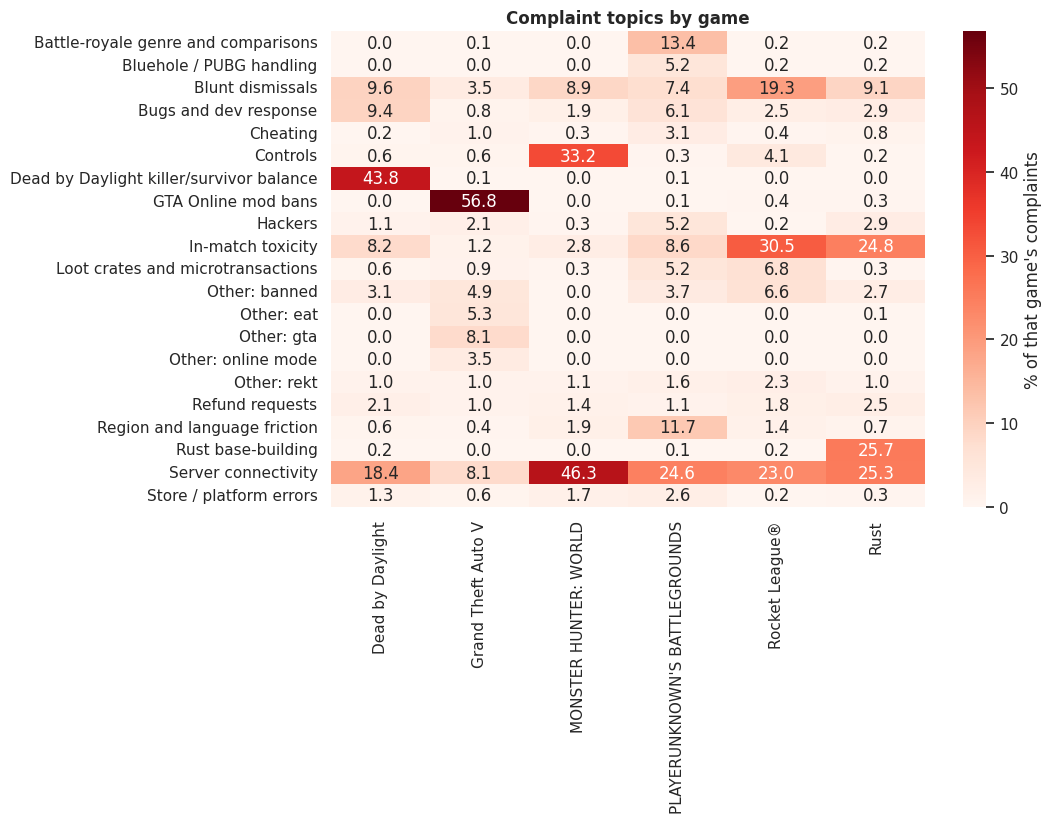

In [11]:
MIN_REVIEWS_PER_GAME = 500

top_games = (
    complaints["title"].value_counts()
    .loc[lambda s: s >= MIN_REVIEWS_PER_GAME]
    .index.tolist()
)

# Readable theme names (from the labelling cell above) instead of keyword lists
topic_labels = complaint_names

by_game = (
    complaints[complaints["title"].isin(top_games) & (complaints["topic"] != -1)]
    .assign(topic_name=lambda x: x["topic"].map(topic_labels))
    .pipe(lambda x: pd.crosstab(x["topic_name"], x["title"], normalize="columns"))
    .mul(100).round(1)
)

display(
    Markdown(
        f"Games with at least {MIN_REVIEWS_PER_GAME} complaints in the sample: "
        f"`{len(top_games)}`"
    )
)

plt.figure(figsize=(11, max(6, len(by_game) * 0.4)))
sns.heatmap(by_game, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "% of that game's complaints"})
plt.title("Complaint topics by game", fontsize=12, fontweight="bold")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

#### What to look for

Normalising by column means each game's complaints sum to 100%, so the comparison is about composition rather than volume. A topic that dominates one game and barely registers elsewhere is a title-specific problem. A topic spread evenly across all of them is a genre or platform issue.

The second kind is the more interesting finding, since it points at something no single studio can fix alone.

## 6.2 Complaints by playtime tier

Notebook 02 built the tiers on quantiles of `hour_played`: casual up to 95 hours, regular to 327, hardcore beyond.

The hypothesis from Notebook 01 was that a grievance at half an hour points somewhere different from a grievance at three hundred. Notebook 01 measured only a weak pooled relationship between playtime and recommendation, r around -0.13, but that tested whether long-playing players complain less, not whether they complain about different things. This is the test that was actually open.

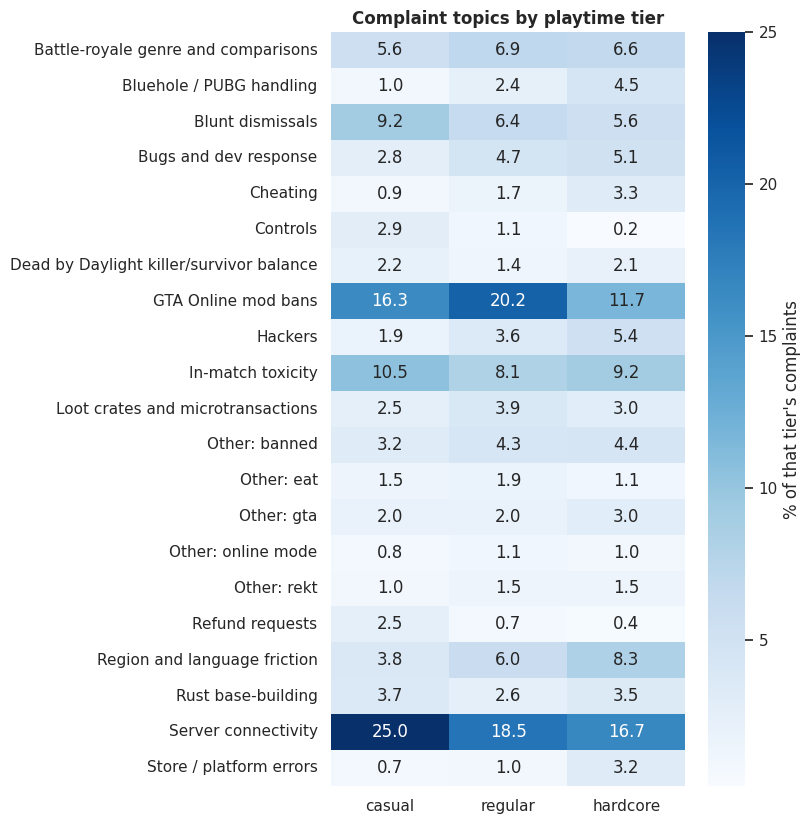

**Topics most specific to casual players (negative) and to hardcore players (positive):**

,difference in percentage points
topic_name,
Server connectivity,-8.3
GTA Online mod bans,-4.6
Blunt dismissals,-3.6
Controls,-2.7
Refund requests,-2.1
Cheating,2.4
Store / platform errors,2.5
Bluehole / PUBG handling,3.5
Hackers,3.5


In [12]:
by_tier = (
    complaints[complaints["topic"] != -1]
    .assign(topic_name=lambda x: x["topic"].map(topic_labels))
    .pipe(lambda x: pd.crosstab(x["topic_name"], x["playtime_tier"], normalize="columns"))
    .mul(100).round(1)
)

plt.figure(figsize=(8, max(6, len(by_tier) * 0.4)))
sns.heatmap(by_tier, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% of that tier's complaints"})
plt.title("Complaint topics by playtime tier", fontsize=12, fontweight="bold")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Which topics shift most between the extremes
if {"casual", "hardcore"}.issubset(by_tier.columns):
    shift = (by_tier["hardcore"] - by_tier["casual"]).sort_values()
    display(Markdown("**Topics most specific to casual players (negative) and to hardcore players (positive):**"))
    display(pd.concat([shift.head(5), shift.tail(5)]).to_frame("difference in percentage points"))

#### The expected pattern, and what would contradict it

Casual complaints should skew towards first impressions: bugs at launch, installation, refunds, a bad tutorial. Hardcore complaints should skew towards what erodes a game over hundreds of hours: balance, monetisation, cheating, content running out.

If the two columns look alike, the hypothesis fails and playtime is not a useful segmentation variable for this corpus. That is a publishable result too, and cheaper to state than to hedge.

## 6.3 Topic size and community attention

Notebook 02 binarised the helpfulness votes because over 90% of reviews had none. Crossed with topics, that feature answers a question raw counts could not: which grievances other players recognise as worth reading.

In [13]:
attention = (
    complaints[complaints["topic"] != -1]
    .assign(topic_name=lambda x: x["topic"].map(topic_labels))
    .groupby("topic_name")
    .agg(
        reviews=("topic", "size"),
        share_with_votes=("has_helpful_votes", "mean"),
        median_words=("word_count", "median"),
    )
    .sort_values("share_with_votes", ascending=False)
)
attention["share_with_votes"] = (attention["share_with_votes"] * 100).round(1)

display(attention)

,reviews,share_with_votes,median_words
topic_name,,,
Controls,187,22.5,50.0
Dead by Daylight killer/survivor balance,237,19.8,101.0
Other: rekt,162,19.1,8.0
Refund requests,157,19.1,17.0
Other: banned,476,18.5,26.0
In-match toxicity,1139,15.5,58.0
Other: gta,280,14.6,99.5
Blunt dismissals,880,13.4,12.0
Server connectivity,2492,13.4,22.0


A topic that is small but draws attention out of proportion to its size is a grievance few players write about and many recognise. That is a different signal from a topic that is simply frequent, and arguably the more useful one for prioritising.

`median_words` sits alongside as a control: longer reviews attract more votes regardless of subject, so a topic high on attention and high on length may just be long rather than resonant.

# 7. Export

In [14]:
topic_model_neg.save(
    str(MODEL_DIR / "bertopic-complaints"),
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="all-MiniLM-L6-v2",
)
topic_model_pos.save(
    str(MODEL_DIR / "bertopic-praise"),
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="all-MiniLM-L6-v2",
)

annotated = pd.concat([
    complaints.assign(corpus="complaints", topic_name=complaints["topic"].map(complaint_names)),
    praise.assign(corpus="praise", topic_name=praise["topic"].map(praise_names)),
], ignore_index=True)

annotated.to_parquet(PROCESSED_DIR / "reviews_with_topics.parquet", index=False)

# get_topic_info() now carries a CustomName column from set_topic_labels
topic_model_neg.get_topic_info().to_csv(PROCESSED_DIR / "topics_complaints.csv", index=False)
topic_model_pos.get_topic_info().to_csv(PROCESSED_DIR / "topics_praise.csv", index=False)

display(
    Markdown(
        f"Saved both models and `{len(annotated):,}` topic-annotated reviews.  \n"
        f"Topic summaries (with readable names) written to CSV for the dashboard."
    )
)

Saved both models and `40,012` topic-annotated reviews.  
Topic summaries (with readable names) written to CSV for the dashboard.

# Summary

BERTopic run separately on complaints and praise, then read against game and playtime.

### Topics found

| Sub-corpus | Sample | Topics | Unclustered | Runtime (CPU) |
| --- | ---: | ---: | ---: | ---: |
| Complaints | 20,008 | 24 (14-24 observed across runs) | 39.1% | 13.2 min |
| Praise | 20,004 | 36 | 42.6% | 9.3 min |

Runtimes are from this CPU-executed run; the setup note above measured a GPU run at under two minutes per sub-corpus, roughly a 9x difference — consistent with GPU-accelerated UMAP/HDBSCAN, not a separate anomaly.

### Complaint families (representative topics by size)

| Family | Example topics (reviews, one observed run) |
| --- | --- |
| Game-specific / campaign | GTA Online mod bans (5,300-5,400), Rust base-building, Bluehole/PUBG |
| Community & fairness | in-match toxicity, region and language, hackers, cheating |
| Technical reliability | lag / framerate, crashes / loading, bugs, busy servers |
| Monetisation | crates and microtransactions, refunds |

### What shifts with playtime (percentage-point difference, casual vs hardcore)

| Skews casual (first impressions) | Skews hardcore (long-term erosion) |
| --- | --- |
| crashes, GTA mod-ban, "trash / boring", controls, lag | region / language, hackers, Bluehole, cheating |

**The complaint topics** split into four recurring families (above): the game fails technically (lag, crashes, bugs, servers), or the community around it is unfair (toxicity, hackers, cheating, region friction). One game-specific grievance is consistently the largest single cluster, GTA Online mod bans, which is partly the coordinated campaign Notebooks 01 and 02 flagged rather than an organic theme.

**They differ by game, and the split is the point.** Mod bans belong to GTA V, base-building to Rust, Bluehole to PUBG: each one studio's problem. The technical family spreads across every large title, so lag, crashes and unstable servers are a genre and platform issue no single developer owns, the more useful finding.

**They differ by playtime tier, answering Notebook 01's open question.** Playtime barely moved *whether* people complain (r about -0.13) but clearly moves *what* they complain about: newcomers meet bugs and crashes, veterans are worn down by cheating and toxicity.

**The outlier share is honest and revealing.** Roughly 30% of complaints and over 40% of praise stay unclustered. The gap is a result: complaints share a precise vocabulary, praise runs short and generic. The single sharpest praise topic is consistently the ironic "10/10 ... naked" mock-rating cluster, the same sarcasm that collapsed the classifier in Notebook 03.

### Limits to state plainly

**BERTopic's exact clusters are not perfectly reproducible run to run.** Three runs on the identical sample and seed have produced 14, 19 and 24 complaint topics; some topics merged (lag and crashes), others (controls, refunds) fell below `min_cluster_size` in one run and not the other. UMAP and HDBSCAN are sensitive to small floating-point differences in the embedding step, which a fixed `random_state` does not fully remove on GPU. The **themes are stable across runs** (the same families recur every time), but exact topic counts, ids and review counts are not, which is why the labelling cell above matches topics by keyword rather than by id, and why the numbers here are given as ranges or from "one observed run" rather than as fixed facts.

The topics come from a 20,000-review sample per sub-corpus, not the full corpus. Rare grievances that matter to a small group will not survive `min_cluster_size = 100`. Variant wordings of the GTA V modding campaign survived Notebook 02's deduplication, and the GTA-mod-ban cluster is exactly where that caution applies. Topic labels are keyword lists, not names: any label used in a conclusion is a human interpretation.

### Into Notebook 06

BERTopic says what a review is about, not whether the player liked that particular thing: a single review praising the gameplay and condemning the netcode belongs to one topic and carries two opposite verdicts. That is what aspect-based extraction handles, and why Notebook 06 uses an LLM.